# MILPÍN AgTech — XGBoost v7.0 — Anti-Degradación + Residual Modeling
## Consumo Hídrico Agrícola — Valle del Yaqui, Sonora — DR-041, Módulo 3

**v7.0 · 2026-05-25** — Correcciones estructurales sobre v6 (RMSE_op degradó 27.8%)

### Problemas detectados en v6 y soluciones aplicadas en v7

| # | Problema v6 | Solución v7 |
|---|---|---|
| A | `agua_neta_req_m3ha` idéntica a `vol_teorico_m3ha` (multicolinealidad perfecta) | Eliminada del modelo |
| B | 2 de 13 constraints con signo incorrecto según SHAP | Auditoría con Pearson + deciles + corrección |
| C | `vol_teorico_m3ha` domina con SHAP=0.41 — ML no agrega valor | Residual modeling: predice (y − vol_teorico) |
| D | Optuna: 50 trials, 50K muestras, lr=0.016 → underfitting | 150 trials, 200K muestras, lr range ampliado |
| E | Entrenamiento en log1p ≠ RMSE_op en escala original | Sin log1p, escala original |
| F | Early stopping en log-Huber, no en RMSE_op | Custom eval metric = RMSE_op real |
| G | Stacking con 3 XGBoost de distinto depth (poca diversidad) | XGBoost + ExtraTrees + Ridge |

**KPI objetivo:** RMSE_op < 738 m³/ha (superar v4) → meta agresiva: < 650 m³/ha


## 0. Imports y configuración global

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor
import xgboost as xgb

try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False; print('[WARN] pip install optuna')

# Constantes
N_SAMPLES      = 1_000_000
SEED           = 42
ANNO_RANGO     = (2014, 2024)
TARIFA         = 1.68
PESO_OP        = 3.0
CULTIVOS       = ['Maiz', 'Frijol', 'Algodon', 'Uva', 'Chile']
OPTUNA_TRIALS  = 150      # v7: era 50
OPTUNA_N       = 200_000  # v7: era 50_000

# Placeholders (se sobreescriben con datos reales en Sec 2)
BASELINE_AGUA = 11_000.0; RANGO_OP_MIN = 6_000.0; RANGO_OP_MAX = 14_000.0

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
C_AGUA='#2e7fb8'; C_REND='#4caf6f'; C_WARN='#e07b39'; C_DARK='#1a2636'
C_BG='#f7f9fb'; C_LINE='#d0d7e2'
CULT_COLORS = {'Maiz':'#e6a817','Frijol':'#8b5e3c','Algodon':'#7ab8d9','Uva':'#9b59b6','Chile':'#e74c3c'}

print(f'XGBoost {xgb.__version__} | numpy {np.__version__} | pandas {pd.__version__}')
print(f'v7: OPTUNA_TRIALS={OPTUNA_TRIALS}, OPTUNA_N={OPTUNA_N:,}')


XGBoost 3.2.0 | numpy 2.4.4 | pandas 3.0.3
v7: OPTUNA_TRIALS=150, OPTUNA_N=200,000


## 1. Generador de datos sintéticos (sin cambios vs v6)

In [2]:
REGIONES_CFG = {
    'Norte':   dict(et0_bias=+0.40, lluvia_mult=0.82, sal_base=0.08, wt_m=3.2, elev_m=35),
    'Sur':     dict(et0_bias=+0.12, lluvia_mult=1.05, sal_base=0.04, wt_m=5.1, elev_m=22),
    'Centro':  dict(et0_bias=+0.00, lluvia_mult=1.00, sal_base=0.05, wt_m=4.6, elev_m=40),
    'Oriente': dict(et0_bias=-0.25, lluvia_mult=1.18, sal_base=0.03, wt_m=6.3, elev_m=85),
    'Costero': dict(et0_bias=+0.28, lluvia_mult=0.88, sal_base=0.14, wt_m=2.4, elev_m=12),
}
FARMER_TYPES = {
    'conservador': dict(over_irr_mu=0.22, over_irr_sd=0.08, p_miss=0.04),
    'eficiente':   dict(over_irr_mu=0.01, over_irr_sd=0.03, p_miss=0.01),
    'negligente':  dict(over_irr_mu=-0.12,over_irr_sd=0.15, p_miss=0.18),
    'tecnificado': dict(over_irr_mu=0.00, over_irr_sd=0.02, p_miss=0.005),
}
KC_STAGES = {
    'Maiz':    dict(kc_ini=0.30,kc_dev=0.70,kc_med=1.20,kc_fin=0.60,f_ini=0.10,f_dev=0.30,f_med=0.50,f_fin=0.10),
    'Frijol':  dict(kc_ini=0.40,kc_dev=0.70,kc_med=1.15,kc_fin=0.55,f_ini=0.10,f_dev=0.35,f_med=0.40,f_fin=0.15),
    'Algodon': dict(kc_ini=0.45,kc_dev=0.75,kc_med=1.20,kc_fin=0.60,f_ini=0.08,f_dev=0.30,f_med=0.45,f_fin=0.17),
    'Uva':     dict(kc_ini=0.30,kc_dev=0.65,kc_med=0.85,kc_fin=0.45,f_ini=0.15,f_dev=0.35,f_med=0.35,f_fin=0.15),
    'Chile':   dict(kc_ini=0.40,kc_dev=0.75,kc_med=1.05,kc_fin=0.80,f_ini=0.12,f_dev=0.30,f_med=0.45,f_fin=0.13),
}
SAL_THRESH = {'Maiz':1.7,'Frijol':1.0,'Algodon':7.7,'Uva':1.5,'Chile':1.5}
SAL_SLOPE  = {'Maiz':12, 'Frijol':19,'Algodon':5.2,'Uva':9.6,'Chile':14}

def generar_datos(n=50_000, seed=42, anno_rango=(2014,2024)):
    rng = np.random.default_rng(seed)
    SUELOS   = ['franco','franco-arcilloso','franco-arenoso','arcilloso']
    SISTEMAS = ['gravedad','aspersion','goteo','microaspersion']
    REGIONES = list(REGIONES_CFG.keys())
    FARMERS  = list(FARMER_TYPES.keys())
    CULT_P = {
        'Maiz':    dict(dias=(130,150),ky=1.25,ym=10.5),
        'Frijol':  dict(dias=(90,110), ky=1.15,ym=2.5),
        'Algodon': dict(dias=(165,200),ky=0.85,ym=4.0),
        'Uva':     dict(dias=(180,215),ky=0.85,ym=25.0),
        'Chile':   dict(dias=(110,130),ky=1.10,ym=35.0),
    }
    SUELO_P = {
        'franco':           dict(cc=0.30,pmp=0.16,ks_mmh=15),
        'franco-arcilloso': dict(cc=0.36,pmp=0.20,ks_mmh=6),
        'franco-arenoso':   dict(cc=0.24,pmp=0.12,ks_mmh=30),
        'arcilloso':        dict(cc=0.42,pmp=0.22,ks_mmh=3),
    }
    EFIC = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
    ci=rng.integers(0,len(CULTIVOS),n); si=rng.integers(0,len(SUELOS),n)
    ri=rng.integers(0,len(SISTEMAS),n); gi=rng.integers(0,len(REGIONES),n)
    fi=rng.integers(0,len(FARMERS),n)
    cultivos=np.array(CULTIVOS)[ci]; suelos=np.array(SUELOS)[si]
    sistemas=np.array(SISTEMAS)[ri]; regiones=np.array(REGIONES)[gi]
    farmers=np.array(FARMERS)[fi]
    annos=rng.integers(anno_rango[0],anno_rango[1]+1,n)
    ky_a=np.array([CULT_P[c]['ky'] for c in CULTIVOS])[ci]
    ym_a=np.array([CULT_P[c]['ym'] for c in CULTIVOS])[ci]
    dmin=np.array([CULT_P[c]['dias'][0] for c in CULTIVOS])[ci]
    dmax=np.array([CULT_P[c]['dias'][1] for c in CULTIVOS])[ci]
    cc_a=np.array([SUELO_P[s]['cc'] for s in SUELOS])[si]
    pmp_a=np.array([SUELO_P[s]['pmp'] for s in SUELOS])[si]
    ks_a=np.array([SUELO_P[s]['ks_mmh'] for s in SUELOS])[si]
    ef_a=np.array([EFIC[s] for s in SISTEMAS])[ri]
    r_et0=np.array([REGIONES_CFG[r]['et0_bias'] for r in REGIONES])[gi]
    r_lluv=np.array([REGIONES_CFG[r]['lluvia_mult'] for r in REGIONES])[gi]
    r_sal=np.array([REGIONES_CFG[r]['sal_base'] for r in REGIONES])[gi]
    r_wt=np.array([REGIONES_CFG[r]['wt_m'] for r in REGIONES])[gi]
    r_elev=np.array([REGIONES_CFG[r]['elev_m'] for r in REGIONES])[gi]
    f_mu=np.array([FARMER_TYPES[f]['over_irr_mu'] for f in FARMERS])[fi]
    f_sd=np.array([FARMER_TYPES[f]['over_irr_sd'] for f in FARMERS])[fi]
    f_miss=np.array([FARMER_TYPES[f]['p_miss'] for f in FARMERS])[fi]
    area_ha=rng.uniform(5.0,80.0,n).round(2)
    doy=rng.integers(1,365,n)
    dias_ciclo=(dmin+rng.random(n)*(dmax-dmin)).astype(int)
    prof_raiz=rng.uniform(0.45,0.70,n).round(3)
    anno_span=max(anno_rango[1]-anno_rango[0],1)
    anno_norm=(annos-anno_rango[0])/anno_span
    et0_drift=anno_norm*0.022*anno_span
    enso_v=np.random.default_rng(seed+9999).normal(0,0.28,anno_span+1)
    enso_a=enso_v[annos-anno_rango[0]]
    et0_s=6.0+2.5*np.sin(2*np.pi*(doy-81)/365)
    et0_r=np.where(enso_a>0.15,et0_s*rng.uniform(1.05,1.28,n),et0_s*rng.uniform(0.88,1.05,n))
    et0_prom=np.clip(et0_r+r_et0+et0_drift+rng.normal(0,0.55,n),2.8,11.0).round(3)
    et0_max=np.clip(et0_prom*rng.uniform(1.15,1.65,n),et0_prom+0.3,12.5).round(3)
    es_ver=(doy>=152)&(doy<=273)
    lluvia=np.clip(
        np.where(es_ver,rng.gamma(2.2,55.0,n),rng.gamma(0.9,18.0,n))*r_lluv*(1+enso_a*0.35)
        +rng.normal(0,4,n), 0, 400).round(2)
    pos_ciclo=rng.beta(1.5,1.5,n)
    kc_stage=np.full(n,0.7)
    for ci_k,cultivo in enumerate(CULTIVOS):
        mask=ci==ci_k
        if not mask.any(): continue
        s=KC_STAGES[cultivo]; pos=pos_ciclo[mask]
        f2=s['f_ini']+s['f_dev']; f3=f2+s['f_med']
        kc_stage[mask]=np.where(pos<s['f_ini'],s['kc_ini'],
            np.where(pos<f2,s['kc_ini']+(s['kc_med']-s['kc_ini'])*(pos-s['f_ini'])/s['f_dev'],
            np.where(pos<f3,s['kc_med'],
                s['kc_med']+(s['kc_fin']-s['kc_med'])*(pos-f2-s['f_med'])/max(s['f_fin'],1e-6))))
    kc_prom=np.clip(kc_stage+rng.normal(0,0.018,n),0.22,1.30).round(3)
    sal_ec=np.clip(r_sal+rng.gamma(1.5,1.2,n),0.01,9.0).round(3)
    sal_th=np.array([SAL_THRESH[c] for c in CULTIVOS])[ci]
    sal_sl=np.array([SAL_SLOPE[c] for c in CULTIVOS])[ci]
    ks_sal=np.clip(1.0-sal_sl/100*np.maximum(0,sal_ec-sal_th),0.05,1.0)
    ola_calor=rng.random(n)<0.10
    helada=(rng.random(n)<0.06)&((doy>=300)|(doy<=60))
    inundacion=(rng.random(n)<0.04)&es_ver
    f_inund_a=np.where(inundacion,rng.uniform(1.10,1.40,n),1.0)
    plaga=rng.random(n)<0.12
    f_plaga=np.where(plaga,rng.uniform(0.60,0.96,n),1.0)
    f_helada=np.where(helada,rng.uniform(0.30,0.75,n),1.0)
    falla=rng.random(n)<f_miss
    aporte_cap=np.where(r_wt<3.5,
        np.clip((3.5-r_wt)*rng.uniform(0.4,1.8,n)*dias_ciclo/100,0,80),0.0).round(2)
    perc_frac=np.clip((1-ef_a)*0.35+(ks_a/30.0)*0.12+rng.uniform(0,0.06,n),0.02,0.38).round(4)
    etc_total=np.clip(et0_prom*dias_ciclo*kc_prom,180,2800).round(2)
    deficit_hid=np.where(rng.random(n)<np.clip((1-ef_a)*0.28,0,0.38),
        rng.beta(1.2,3.5,n)*0.55,0.0).round(4)
    deficit_hid=np.where(falla,np.clip(deficit_hid+rng.uniform(0.08,0.32,n),0,0.65),deficit_hid)
    agua_disp=(cc_a-pmp_a)*prof_raiz*1000
    over_irr=np.clip(1.0+f_mu+rng.normal(0,f_sd,n),0.55,1.70)
    n_riegos=np.clip(np.maximum(1,np.round(
        (etc_total-lluvia).clip(0)/(agua_disp*0.6)).astype(int)+rng.integers(-1,2,n)),1,40)
    deficit_agua=np.maximum(0,etc_total-lluvia-aporte_cap)
    vol_base=deficit_agua*10/ef_a*over_irr*f_inund_a
    vol_agua=np.clip(vol_base+rng.normal(0,180,n),1_200,28_000).round(2)
    ks_water=1.0-deficit_hid
    ya_frac=np.clip(1-ky_a*(1-ks_water),0.05,1.0)
    rendimiento=np.clip(ym_a*ya_frac*ks_sal*f_helada*f_plaga*
        np.where(inundacion,rng.uniform(0.50,0.85,n),1.0)*rng.normal(1.0,0.08,n),
        0.2,ym_a*1.2).round(3)
    return pd.DataFrame({
        'cultivo':cultivos,'tipo_suelo':suelos,'sistema_riego':sistemas,
        'region':regiones,'tipo_agricultor':farmers,
        'area_ha':area_ha,'dias_ciclo':dias_ciclo,'doy_inicio':doy,
        'capacidad_campo':cc_a,'punto_marchitez':pmp_a,'prof_raiz_m':prof_raiz,
        'et0_promedio_mmdia':et0_prom,'et0_maximo_mmdia':et0_max,
        'lluvia_total_mm':lluvia,'etc_total_mm':etc_total,'kc_promedio':kc_prom,
        'deficit_hidrico_frac':deficit_hid,'n_riegos':n_riegos,
        'volumen_agua_total_m3_ha':vol_agua,'rendimiento_real_ton_ha':rendimiento,
        'anno':annos,'anno_norm':anno_norm,'pos_ciclo_frac':pos_ciclo,
        'salinidad_ec_dsm':sal_ec,'ks_salinidad':ks_sal,
        'aporte_capilar_mm':aporte_cap,'percolacion_frac':perc_frac,
        'ola_calor':ola_calor.astype(int),'helada':helada.astype(int),
        'inundacion':inundacion.astype(int),'plaga':plaga.astype(int),
        'falla_riego':falla.astype(int),'elev_parcela_m':r_elev,
    })

t0 = time.time()
df = generar_datos(n=N_SAMPLES, seed=SEED, anno_rango=ANNO_RANGO)
print(f'Generados {N_SAMPLES:,} ciclos en {time.time()-t0:.1f}s')
print(f'Shape: {df.shape} | RAM: {df.memory_usage(deep=True).sum()/1e6:.0f} MB')
print(df.groupby('cultivo')['volumen_agua_total_m3_ha'].agg(['mean','std','min','max']).round(0).to_string())



Generados 1,000,000 ciclos en 3.3s
Shape: (1000000, 33) | RAM: 510 MB
            mean     std     min      max
cultivo                                  
Algodon  15927.0  6917.0  1200.0  28000.0
Chile     9132.0  4815.0  1200.0  28000.0
Frijol    8035.0  4356.0  1200.0  28000.0
Maiz     12063.0  6359.0  1200.0  28000.0
Uva      11432.0  6130.0  1200.0  28000.0


In [3]:
def generar_datos(n=50_000, seed=42, anno_rango=(2014,2024)):
    rng = np.random.default_rng(seed)
    SUELOS   = ['franco','franco-arcilloso','franco-arenoso','arcilloso']
    SISTEMAS = ['gravedad','aspersion','goteo','microaspersion']
    REGIONES = list(REGIONES_CFG.keys())
    FARMERS  = list(FARMER_TYPES.keys())
    CULT_P = {
        'Maiz':    dict(dias=(130,150),ky=1.25,ym=10.5),
        'Frijol':  dict(dias=(90,110), ky=1.15,ym=2.5),
        'Algodon': dict(dias=(165,200),ky=0.85,ym=4.0),
        'Uva':     dict(dias=(180,215),ky=0.85,ym=25.0),
        'Chile':   dict(dias=(110,130),ky=1.10,ym=35.0),
    }
    SUELO_P = {
        'franco':           dict(cc=0.30,pmp=0.16,ks_mmh=15),
        'franco-arcilloso': dict(cc=0.36,pmp=0.20,ks_mmh=6),
        'franco-arenoso':   dict(cc=0.24,pmp=0.12,ks_mmh=30),
        'arcilloso':        dict(cc=0.42,pmp=0.22,ks_mmh=3),
    }
    EFIC = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
    ci=rng.integers(0,len(CULTIVOS),n); si=rng.integers(0,len(SUELOS),n)
    ri=rng.integers(0,len(SISTEMAS),n); gi=rng.integers(0,len(REGIONES),n)
    fi=rng.integers(0,len(FARMERS),n)
    cultivos=np.array(CULTIVOS)[ci]; suelos=np.array(SUELOS)[si]
    sistemas=np.array(SISTEMAS)[ri]; regiones=np.array(REGIONES)[gi]
    farmers=np.array(FARMERS)[fi]
    annos=rng.integers(anno_rango[0],anno_rango[1]+1,n)
    ky_a=np.array([CULT_P[c]['ky'] for c in CULTIVOS])[ci]
    ym_a=np.array([CULT_P[c]['ym'] for c in CULTIVOS])[ci]
    dmin=np.array([CULT_P[c]['dias'][0] for c in CULTIVOS])[ci]
    dmax=np.array([CULT_P[c]['dias'][1] for c in CULTIVOS])[ci]
    cc_a=np.array([SUELO_P[s]['cc'] for s in SUELOS])[si]
    pmp_a=np.array([SUELO_P[s]['pmp'] for s in SUELOS])[si]
    ks_a=np.array([SUELO_P[s]['ks_mmh'] for s in SUELOS])[si]
    ef_a=np.array([EFIC[s] for s in SISTEMAS])[ri]
    r_et0=np.array([REGIONES_CFG[r]['et0_bias'] for r in REGIONES])[gi]
    r_lluv=np.array([REGIONES_CFG[r]['lluvia_mult'] for r in REGIONES])[gi]
    r_sal=np.array([REGIONES_CFG[r]['sal_base'] for r in REGIONES])[gi]
    r_wt=np.array([REGIONES_CFG[r]['wt_m'] for r in REGIONES])[gi]
    r_elev=np.array([REGIONES_CFG[r]['elev_m'] for r in REGIONES])[gi]
    f_mu=np.array([FARMER_TYPES[f]['over_irr_mu'] for f in FARMERS])[fi]
    f_sd=np.array([FARMER_TYPES[f]['over_irr_sd'] for f in FARMERS])[fi]
    f_miss=np.array([FARMER_TYPES[f]['p_miss'] for f in FARMERS])[fi]
    area_ha=rng.uniform(5.0,80.0,n).round(2)
    doy=rng.integers(1,365,n)
    dias_ciclo=(dmin+rng.random(n)*(dmax-dmin)).astype(int)
    prof_raiz=rng.uniform(0.45,0.70,n).round(3)
    anno_span=max(anno_rango[1]-anno_rango[0],1)
    anno_norm=(annos-anno_rango[0])/anno_span
    et0_drift=anno_norm*0.022*anno_span
    enso_v=np.random.default_rng(seed+9999).normal(0,0.28,anno_span+1)
    enso_a=enso_v[annos-anno_rango[0]]
    et0_s=6.0+2.5*np.sin(2*np.pi*(doy-81)/365)
    et0_r=np.where(enso_a>0.15,et0_s*rng.uniform(1.05,1.28,n),et0_s*rng.uniform(0.88,1.05,n))
    et0_prom=np.clip(et0_r+r_et0+et0_drift+rng.normal(0,0.55,n),2.8,11.0).round(3)
    et0_max=np.clip(et0_prom*rng.uniform(1.15,1.65,n),et0_prom+0.3,12.5).round(3)
    es_ver=(doy>=152)&(doy<=273)
    lluvia=np.clip(
        np.where(es_ver,rng.gamma(2.2,55.0,n),rng.gamma(0.9,18.0,n))*r_lluv*(1+enso_a*0.35)
        +rng.normal(0,4,n), 0, 400).round(2)
    pos_ciclo=rng.beta(1.5,1.5,n)
    kc_stage=np.full(n,0.7)
    for ci_k,cultivo in enumerate(CULTIVOS):
        mask=ci==ci_k
        if not mask.any(): continue
        s=KC_STAGES[cultivo]; pos=pos_ciclo[mask]
        f2=s['f_ini']+s['f_dev']; f3=f2+s['f_med']
        kc_stage[mask]=np.where(pos<s['f_ini'],s['kc_ini'],
            np.where(pos<f2,s['kc_ini']+(s['kc_med']-s['kc_ini'])*(pos-s['f_ini'])/s['f_dev'],
            np.where(pos<f3,s['kc_med'],
                s['kc_med']+(s['kc_fin']-s['kc_med'])*(pos-f2-s['f_med'])/max(s['f_fin'],1e-6))))
    kc_prom=np.clip(kc_stage+rng.normal(0,0.018,n),0.22,1.30).round(3)
    sal_ec=np.clip(r_sal+rng.gamma(1.5,1.2,n),0.01,9.0).round(3)
    sal_th=np.array([SAL_THRESH[c] for c in CULTIVOS])[ci]
    sal_sl=np.array([SAL_SLOPE[c] for c in CULTIVOS])[ci]
    ks_sal=np.clip(1.0-sal_sl/100*np.maximum(0,sal_ec-sal_th),0.05,1.0)
    ola_calor=rng.random(n)<0.10
    helada=(rng.random(n)<0.06)&((doy>=300)|(doy<=60))
    inundacion=(rng.random(n)<0.04)&es_ver
    f_inund_a=np.where(inundacion,rng.uniform(1.10,1.40,n),1.0)
    plaga=rng.random(n)<0.12
    f_plaga=np.where(plaga,rng.uniform(0.60,0.96,n),1.0)
    f_helada=np.where(helada,rng.uniform(0.30,0.75,n),1.0)
    falla=rng.random(n)<f_miss
    aporte_cap=np.where(r_wt<3.5,
        np.clip((3.5-r_wt)*rng.uniform(0.4,1.8,n)*dias_ciclo/100,0,80),0.0).round(2)
    perc_frac=np.clip((1-ef_a)*0.35+(ks_a/30.0)*0.12+rng.uniform(0,0.06,n),0.02,0.38).round(4)
    etc_total=np.clip(et0_prom*dias_ciclo*kc_prom,180,2800).round(2)
    deficit_hid=np.where(rng.random(n)<np.clip((1-ef_a)*0.28,0,0.38),
        rng.beta(1.2,3.5,n)*0.55,0.0).round(4)
    deficit_hid=np.where(falla,np.clip(deficit_hid+rng.uniform(0.08,0.32,n),0,0.65),deficit_hid)
    agua_disp=(cc_a-pmp_a)*prof_raiz*1000
    over_irr=np.clip(1.0+f_mu+rng.normal(0,f_sd,n),0.55,1.70)
    n_riegos=np.clip(np.maximum(1,np.round(
        (etc_total-lluvia).clip(0)/(agua_disp*0.6)).astype(int)+rng.integers(-1,2,n)),1,40)
    deficit_agua=np.maximum(0,etc_total-lluvia-aporte_cap)
    vol_base=deficit_agua*10/ef_a*over_irr*f_inund_a
    vol_agua=np.clip(vol_base+rng.normal(0,180,n),1_200,28_000).round(2)
    ks_water=1.0-deficit_hid
    ya_frac=np.clip(1-ky_a*(1-ks_water),0.05,1.0)
    rendimiento=np.clip(ym_a*ya_frac*ks_sal*f_helada*f_plaga*
        np.where(inundacion,rng.uniform(0.50,0.85,n),1.0)*rng.normal(1.0,0.08,n),
        0.2,ym_a*1.2).round(3)
    return pd.DataFrame({
        'cultivo':cultivos,'tipo_suelo':suelos,'sistema_riego':sistemas,
        'region':regiones,'tipo_agricultor':farmers,
        'area_ha':area_ha,'dias_ciclo':dias_ciclo,'doy_inicio':doy,
        'capacidad_campo':cc_a,'punto_marchitez':pmp_a,'prof_raiz_m':prof_raiz,
        'et0_promedio_mmdia':et0_prom,'et0_maximo_mmdia':et0_max,
        'lluvia_total_mm':lluvia,'etc_total_mm':etc_total,'kc_promedio':kc_prom,
        'deficit_hidrico_frac':deficit_hid,'n_riegos':n_riegos,
        'volumen_agua_total_m3_ha':vol_agua,'rendimiento_real_ton_ha':rendimiento,
        'anno':annos,'anno_norm':anno_norm,'pos_ciclo_frac':pos_ciclo,
        'salinidad_ec_dsm':sal_ec,'ks_salinidad':ks_sal,
        'aporte_capilar_mm':aporte_cap,'percolacion_frac':perc_frac,
        'ola_calor':ola_calor.astype(int),'helada':helada.astype(int),
        'inundacion':inundacion.astype(int),'plaga':plaga.astype(int),
        'falla_riego':falla.astype(int),'elev_parcela_m':r_elev,
    })

t0 = time.time()
df = generar_datos(n=N_SAMPLES, seed=SEED, anno_rango=ANNO_RANGO)
print(f'Generados {N_SAMPLES:,} ciclos en {time.time()-t0:.1f}s')
print(f'Shape: {df.shape} | RAM: {df.memory_usage(deep=True).sum()/1e6:.0f} MB')
print(df.groupby('cultivo')['volumen_agua_total_m3_ha'].agg(['mean','std','min','max']).round(0).to_string())


Generados 1,000,000 ciclos en 3.3s
Shape: (1000000, 33) | RAM: 510 MB
            mean     std     min      max
cultivo                                  
Algodon  15927.0  6917.0  1200.0  28000.0
Chile     9132.0  4815.0  1200.0  28000.0
Frijol    8035.0  4356.0  1200.0  28000.0
Maiz     12063.0  6359.0  1200.0  28000.0
Uva      11432.0  6130.0  1200.0  28000.0


In [4]:
TARGET = 'volumen_agua_total_m3_ha'
crop_stats = (
    df.groupby('cultivo')[TARGET]
    .agg(baseline_m3ha=lambda x: x.median(), objetivo_m3ha=lambda x: x.median()*0.75,
         op_min_q25=lambda x: x.quantile(0.25), op_max_q75=lambda x: x.quantile(0.75))
    .round(0)
)
print(crop_stats.to_string())
BASELINE_CROP = crop_stats['baseline_m3ha'].to_dict()
OBJETIVO_CROP = crop_stats['objetivo_m3ha'].to_dict()
OP_MIN_CROP   = crop_stats['op_min_q25'].to_dict()
OP_MAX_CROP   = crop_stats['op_max_q75'].to_dict()
BASELINE_AGUA = float(df[TARGET].median())
RANGO_OP_MIN  = float(df[TARGET].quantile(0.25))
RANGO_OP_MAX  = float(df[TARGET].quantile(0.75))

def calc_weights_dynamic(y_arr, cultivo_arr, w_op=PESO_OP):
    w = np.ones(len(y_arr))
    for c in CULTIVOS:
        m = cultivo_arr == c
        if not m.any(): continue
        w[m & (y_arr >= OP_MIN_CROP[c]) & (y_arr <= OP_MAX_CROP[c])] = w_op
    return w

def rmse(yt, yp): return float(np.sqrt(np.mean((yt-yp)**2)))

def metricas(y_true, y_pred, nombre='Modelo', cultivo=None):
    lo = OP_MIN_CROP.get(cultivo, RANGO_OP_MIN) if cultivo else RANGO_OP_MIN
    hi = OP_MAX_CROP.get(cultivo, RANGO_OP_MAX) if cultivo else RANGO_OP_MAX
    mask = (y_true >= lo) & (y_true <= hi)
    if not mask.any():
        return {'Modelo': nombre, 'RMSE_global': rmse(y_true, y_pred), 'RMSE_op': np.nan}
    rmse_op = rmse(y_true[mask], y_pred[mask])
    return {'Modelo': nombre, 'RMSE_global': rmse(y_true, y_pred), 'RMSE_op': rmse_op,
            'R2_op': r2_score(y_true[mask], y_pred[mask]),
            'Error_MXN_ha': round(rmse_op * TARIFA, 0), 'N_op': int(mask.sum())}

def rmse_op_v2(y_true, y_pred, cultivos_arr):
    mask = np.zeros(len(y_true), dtype=bool)
    for c in CULTIVOS:
        cm = cultivos_arr == c
        mask |= (cm & (y_true >= OP_MIN_CROP[c]) & (y_true <= OP_MAX_CROP[c]))
    return float(np.sqrt(np.mean((y_true[mask]-y_pred[mask])**2))) if mask.any() else np.nan

ALL_RESULTS = []
print(f'Global: baseline={BASELINE_AGUA:,.0f}  rango_op=[{RANGO_OP_MIN:,.0f}–{RANGO_OP_MAX:,.0f}]')


         baseline_m3ha  objetivo_m3ha  op_min_q25  op_max_q75
cultivo                                                      
Algodon        15060.0        11295.0     10379.0     21025.0
Chile           8269.0         6202.0      5596.0     11692.0
Frijol          7228.0         5421.0      4847.0     10337.0
Maiz           11156.0         8367.0      7307.0     15834.0
Uva            10303.0         7727.0      6750.0     14956.0
Global: baseline=9,992  rango_op=[6,451–14,882]


## 3. [NUEVO v7] Sección A — Auditoría de Dominancia y Multicolinealidad

### Hallazgo crítico de v6

En v6 se reportaron dos alertas en el análisis SHAP:

1. **`vol_teorico_m3ha` domina con SHAP = 0.41** — una sola feature explica el 40% del modelo.
   El modelo de v6 era básicamente: `predicción ≈ f(vol_teorico) + ruido`.

2. **`agua_neta_req_m3ha` tiene SHAP negativo** cuando la física FAO-56 exige signo positivo.

### Hipótesis

Mirando `feature_engineering()` de v6:
```python
df['vol_teorico_m3ha']   = df['demanda_neta_mm'] * 10 / df['eficiencia_sistema']
df['agua_neta_req_m3ha'] = df['demanda_neta_mm'] / df['eficiencia_sistema'] * 10
```
Son **algebraicamente idénticas**. XGBoost compite entre dos copias de la misma variable:
una recibe SHAP positivo (domina), la otra SHAP negativo (compensa) → artefacto puro.

**Esta celda confirma y corrige el problema.**


In [5]:
# A1. Detectar features algebraicamente idénticas
rng_audit = np.random.default_rng(SEED + 99)
idx_audit  = rng_audit.choice(len(df), 50_000, replace=False)
df_audit   = df.iloc[idx_audit].copy()

EF = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
df_audit['eficiencia_sistema'] = df_audit['sistema_riego'].map(EF)
df_audit['demanda_neta_mm']    = (df_audit['etc_total_mm'] - df_audit['lluvia_total_mm']
                                   - df_audit['aporte_capilar_mm']).clip(0)
df_audit['vol_teorico_m3ha']   = df_audit['demanda_neta_mm'] * 10 / df_audit['eficiencia_sistema']
df_audit['agua_neta_req_m3ha'] = df_audit['demanda_neta_mm'] / df_audit['eficiencia_sistema'] * 10

diff_max = (df_audit['vol_teorico_m3ha'] - df_audit['agua_neta_req_m3ha']).abs().max()
r_dup    = df_audit[['vol_teorico_m3ha','agua_neta_req_m3ha']].corr().iloc[0,1]
r_vt_y   = df_audit[['vol_teorico_m3ha', TARGET]].corr().iloc[0,1]

print(f"Diferencia max entre vol_teorico y agua_neta_req: {diff_max:.2e}")
print(f"Correlacion entre ambas features:                 r = {r_dup:.6f}")
print(f"Correlacion vol_teorico vs target:                r = {r_vt_y:.4f}  (R2 = {r_vt_y**2:.4f})")
print()
if abs(r_dup) > 0.9999:
    print("CONFIRMADO: agua_neta_req_m3ha es identica a vol_teorico_m3ha")
    print("  Causa del SHAP negativo en v6: compensacion por multicolinealidad perfecta")
    print("  Accion: ELIMINAR agua_neta_req_m3ha de FEAT_COLS")
    FEAT_REMOVE = ['agua_neta_req_m3ha']
else:
    print("No son identicas — revisar manualmente")
    FEAT_REMOVE = []

print(f"\nR2 implícito de vol_teorico solo sobre target: {r_vt_y**2:.4f}")
print(f"  => El modelo v6 era ~{r_vt_y**2*100:.0f}% explicado por la teoria FAO-56 directamente")


Diferencia max entre vol_teorico y agua_neta_req: 7.28e-12
Correlacion entre ambas features:                 r = 1.000000
Correlacion vol_teorico vs target:                r = 0.9491  (R2 = 0.9009)

CONFIRMADO: agua_neta_req_m3ha es identica a vol_teorico_m3ha
  Causa del SHAP negativo en v6: compensacion por multicolinealidad perfecta
  Accion: ELIMINAR agua_neta_req_m3ha de FEAT_COLS

R2 implícito de vol_teorico solo sobre target: 0.9009
  => El modelo v6 era ~90% explicado por la teoria FAO-56 directamente


In [6]:
# A2. Correlacion de todas las features clave con el target
key_feats_audit = {
    'vol_teorico_m3ha':   lambda d: d['demanda_neta_mm']*10/d['eficiencia_sistema'],
    'agua_neta_req_m3ha': lambda d: d['demanda_neta_mm']/d['eficiencia_sistema']*10,
    'eficiencia_sistema': lambda d: d['eficiencia_sistema'],
    'demanda_neta_mm':    lambda d: d['demanda_neta_mm'],
    'deficit_agua_mm':    lambda d: (d['etc_total_mm']-d['lluvia_total_mm']).clip(0),
    'stress_hid_ks':      lambda d: (1-d['deficit_hidrico_frac']).clip(0,1),
    'ks_efectivo':        lambda d: d['ks_salinidad']*(1-d['deficit_hidrico_frac']).clip(0,1),
    'kc_stress_efectivo': lambda d: d['kc_promedio']*d['ks_salinidad']*(1-d['deficit_hidrico_frac']).clip(0,1),
    'riego_bruto_mm':     lambda d: d['demanda_neta_mm']/d['eficiencia_sistema'],
    'perdidas_sistema_mm':lambda d: d['demanda_neta_mm']*(1/d['eficiencia_sistema']-1),
    'intervalo_riego_dias':lambda d: d['dias_ciclo']/(d['n_riegos']+1),
    'demanda_diaria_mm':  lambda d: d['demanda_neta_mm']/(d['dias_ciclo']+1),
    'et0_x_kc_stress':    lambda d: d['et0_promedio_mmdia']*d['dias_ciclo']*d['kc_promedio']*d['ks_salinidad'],
}
corr_rows = []
for feat, fn in key_feats_audit.items():
    try:
        vals = fn(df_audit).values
        r    = float(np.corrcoef(vals, df_audit[TARGET].values)[0,1])
        flag = ' <- DUPLICADO CONFIRMADO' if feat == 'agua_neta_req_m3ha' else ''
        corr_rows.append({'Feature': feat, 'Pearson_r': round(r,4), 'R2': round(r**2,4), 'Nota': flag.strip()})
    except Exception as e:
        corr_rows.append({'Feature': feat, 'Pearson_r': None, 'R2': None, 'Nota': str(e)})
df_corr = pd.DataFrame(corr_rows).sort_values('R2', ascending=False, key=lambda x: x.abs())
print("Correlacion de features con target (|r| descendente):")
print(df_corr.to_string(index=False))


Correlacion de features con target (|r| descendente):
             Feature  Pearson_r     R2                    Nota
    vol_teorico_m3ha     0.9491 0.9009                        
  agua_neta_req_m3ha     0.9491 0.9009 <- DUPLICADO CONFIRMADO
      riego_bruto_mm     0.9491 0.9009                        
     deficit_agua_mm     0.8516 0.7253                        
     demanda_neta_mm     0.8516 0.7253                        
     et0_x_kc_stress     0.8037 0.6459                        
 perdidas_sistema_mm     0.7669 0.5881                        
   demanda_diaria_mm     0.7355 0.5409                        
intervalo_riego_dias    -0.5381 0.2895                        
  kc_stress_efectivo     0.4685 0.2195                        
  eficiencia_sistema    -0.4038 0.1630                        
         ks_efectivo     0.1194 0.0143                        
       stress_hid_ks    -0.0252 0.0006                        


## 4. [NUEVO v7] Sección B — Auditoría de Constraints de Monotonicidad

### Problema en v6

v6 impuso 13 constraints sin verificar con los datos.
El propio notebook reportó `[REVISAR]` en 2 de ellos:
- `agua_neta_req_m3ha` (+1): signo SHAP negativo → ya explicado: era duplicado
- `stress_hid_ks` (-1): pendiente real desconocida

Un constraint incorrecto **fuerza al modelo a aprender en dirección equivocada**,
pagando RMSE para satisfacer una restricción que contradice los datos reales.

### Metodología

Para cada feature con constraint: Pearson r + pendiente por deciles → veredicto.


In [7]:
MONOTONE_V6 = {
    'demanda_neta_mm': 1, 'agua_neta_req_m3ha': 1, 'riego_bruto_mm': 1,
    'deficit_agua_mm': 1, 'vol_teorico_m3ha': 1, 'eficiencia_sistema': -1,
    'ks_efectivo': -1, 'perdidas_sistema_mm': 1, 'intervalo_riego_dias': 1,
    'demanda_diaria_mm': 1, 'stress_hid_ks': -1, 'kc_stress_efectivo': 1, 'et0_x_kc_stress': 1,
}

audit_rows = []
for feat, exp_sign in MONOTONE_V6.items():
    if feat not in df_audit.columns:
        audit_rows.append({'Feature': feat, 'Pearson_r': 'N/A',
                           'Decile_slope': 'N/A', 'v6': f'{exp_sign:+d}',
                           'v7': f'{exp_sign:+d}', 'Veredicto': 'Sin datos'})
        continue
    r = df_audit[[feat, TARGET]].corr().iloc[0,1]
    df_audit['_q'] = pd.qcut(df_audit[feat], q=10, duplicates='drop')
    slope = df_audit.groupby('_q')[TARGET].mean()
    decile_sign = +1 if (slope.iloc[-1] > slope.iloc[0]) else -1
    df_audit.drop(columns='_q', inplace=True)
    real_sign = +1 if r > 0 else -1

    if feat == 'agua_neta_req_m3ha':
        verdict = 'ELIMINAR (duplicado vol_teorico)'; v7 = 'eliminada'
    elif real_sign == exp_sign and decile_sign == exp_sign:
        verdict = 'OK — mantener'; v7 = f'{exp_sign:+d}'
    elif real_sign == exp_sign:
        verdict = 'OK Pearson, deciles discrepan'; v7 = f'{exp_sign:+d}'
    else:
        verdict = f'CORREGIR -> real={real_sign:+d}'; v7 = f'{real_sign:+d}'

    audit_rows.append({'Feature': feat, 'Pearson_r': round(r,4),
                       'Decile_slope': '+' if decile_sign>0 else '-',
                       'v6': f'{exp_sign:+d}', 'v7': v7, 'Veredicto': verdict})

df_audit_c = pd.DataFrame(audit_rows)
print("=== AUDITORIA DE CONSTRAINTS v6 vs v7 ===")
print(df_audit_c.to_string(index=False))


=== AUDITORIA DE CONSTRAINTS v6 vs v7 ===
             Feature Pearson_r Decile_slope v6        v7                        Veredicto
     demanda_neta_mm    0.8516            + +1        +1                    OK — mantener
  agua_neta_req_m3ha    0.9491            + +1 eliminada ELIMINAR (duplicado vol_teorico)
      riego_bruto_mm       N/A          N/A +1        +1                        Sin datos
     deficit_agua_mm       N/A          N/A +1        +1                        Sin datos
    vol_teorico_m3ha    0.9491            + +1        +1                    OK — mantener
  eficiencia_sistema   -0.4038            - -1        -1                    OK — mantener
         ks_efectivo       N/A          N/A -1        -1                        Sin datos
 perdidas_sistema_mm       N/A          N/A +1        +1                        Sin datos
intervalo_riego_dias       N/A          N/A +1        +1                        Sin datos
   demanda_diaria_mm       N/A          N/A +1        +1  

In [8]:
# Construir MONOTONE_MAP_V7 desde los veredictos
MONOTONE_MAP_V7 = {}
for row in audit_rows:
    feat = row['Feature']
    v7   = row['v7']
    if v7 == 'eliminada' or v7 == 'N/A':
        continue
    try:
        val = int(v7)
        if val != 0:
            MONOTONE_MAP_V7[feat] = val
    except:
        pass

n_v6 = sum(1 for v in MONOTONE_V6.values() if v != 0)
n_v7 = len(MONOTONE_MAP_V7)
print(f"Constraints activos: v6={n_v6}  ->  v7={n_v7}")
print("\nMONOTONE_MAP_V7 final:")
for k, v in MONOTONE_MAP_V7.items():
    cambio = ' (CORREGIDO)' if v != MONOTONE_V6.get(k, v) else ''
    print(f"  '{k}': {v:+d}{cambio}")


Constraints activos: v6=13  ->  v7=12

MONOTONE_MAP_V7 final:
  'demanda_neta_mm': +1
  'riego_bruto_mm': +1
  'deficit_agua_mm': +1
  'vol_teorico_m3ha': +1
  'eficiencia_sistema': -1
  'ks_efectivo': -1
  'perdidas_sistema_mm': +1
  'intervalo_riego_dias': +1
  'demanda_diaria_mm': +1
  'stress_hid_ks': -1
  'kc_stress_efectivo': +1
  'et0_x_kc_stress': +1


## 5. Feature Engineering v5 — fix multicolinealidad

In [9]:
def feature_engineering(df_in, te_maps=None, fit_te=True):
    df = df_in.copy()
    EF = {'gravedad':0.50,'aspersion':0.75,'goteo':0.90,'microaspersion':0.85}
    df['eficiencia_sistema']   = df['sistema_riego'].map(EF)
    df['demanda_neta_mm']      = (df['etc_total_mm']-df['lluvia_total_mm']-df['aporte_capilar_mm']).clip(0)
    df['vol_teorico_m3ha']     = df['demanda_neta_mm']*10/df['eficiencia_sistema']
    df['deficit_agua_mm']      = (df['etc_total_mm']-df['lluvia_total_mm']).clip(0)
    df['agua_efectiva_mm']     = df['lluvia_total_mm']*df['eficiencia_sistema']
    df['eto_x_dias']           = df['et0_promedio_mmdia']*df['dias_ciclo']
    df['lluvia_etc_ratio']     = df['lluvia_total_mm']/(df['etc_total_mm']+1)
    df['kc_x_et0']             = df['kc_promedio']*df['et0_promedio_mmdia']
    df['ks_sal_x_deficit']     = df['ks_salinidad']*df['deficit_hidrico_frac']
    df['dias_x_kc']            = df['dias_ciclo']*df['kc_promedio']
    df['doy_sin']              = np.sin(2*np.pi*df['doy_inicio']/365)
    df['doy_cos']              = np.cos(2*np.pi*df['doy_inicio']/365)
    df['et0_range']            = df['et0_maximo_mmdia']-df['et0_promedio_mmdia']
    df['riesgo_extremo']       = df['ola_calor']+df['helada']+df['inundacion']+df['plaga']+df['falla_riego']
    df['agua_disponible_mm']   = (df['capacidad_campo']-df['punto_marchitez'])*df['prof_raiz_m']*1000
    df['ratio_demanda_suelo']  = df['etc_total_mm']/(df['agua_disponible_mm']+1)
    df['capilar_sobre_etc']    = df['aporte_capilar_mm']/(df['etc_total_mm']+1)
    df['estres_total']         = df['deficit_hidrico_frac']+(1-df['ks_salinidad'])*0.5
    df['et0_x_anno']           = df['et0_promedio_mmdia']*df['anno_norm']
    df['pos_ciclo_x_kc']       = df['pos_ciclo_frac']*df['kc_promedio']
    # v5 features — NOTA v7: agua_neta_req_m3ha NO se calcula (era duplicado)
    df['riego_bruto_mm']       = df['demanda_neta_mm']/df['eficiencia_sistema']
    df['perdidas_sistema_mm']  = df['demanda_neta_mm']*(1.0/df['eficiencia_sistema']-1.0)
    df['stress_hid_ks']        = (1.0-df['deficit_hidrico_frac']).clip(0,1)
    df['ks_efectivo']          = df['ks_salinidad']*df['stress_hid_ks']
    df['kc_stress_efectivo']   = df['kc_promedio']*df['ks_efectivo']
    df['inundacion_x_perc']    = df['inundacion']*df['percolacion_frac']
    df['seasonal_sin_ciclo']   = np.sin(2*np.pi*df['pos_ciclo_frac'])
    df['seasonal_cos_ciclo']   = np.cos(2*np.pi*df['pos_ciclo_frac'])
    df['intervalo_riego_dias'] = df['dias_ciclo']/(df['n_riegos']+1)
    df['demanda_diaria_mm']    = df['demanda_neta_mm']/(df['dias_ciclo']+1)
    df['capilar_deficit_pct']  = df['aporte_capilar_mm']/(df['deficit_agua_mm']+1)
    df['lluvia_cobertura_frac']= df['lluvia_total_mm']/(df['etc_total_mm']+1)
    df['log_area_ha']          = np.log1p(df['area_ha'])
    df['log_n_riegos']         = np.log1p(df['n_riegos'])
    df['et0_x_kc_stress']      = df['eto_x_dias']*df['kc_stress_efectivo']
    # Target encoding
    CAT_TE = ['tipo_agricultor','region','sistema_riego']
    if fit_te:
        te_maps = {col: df.groupby(col)[TARGET].mean() for col in CAT_TE}
    for col in CAT_TE:
        df[f'te_{col}'] = df[col].map(te_maps[col]).fillna(BASELINE_AGUA)
    return df, te_maps

print("feature_engineering v7: agua_neta_req_m3ha eliminada (era duplicado de vol_teorico_m3ha)")


feature_engineering v7: agua_neta_req_m3ha eliminada (era duplicado de vol_teorico_m3ha)


## 6. Preprocessing Pipeline

In [10]:
CAT_COLS    = ['cultivo','tipo_suelo','sistema_riego','region','tipo_agricultor']
LEAKAGE_FEATS = ['ratio_real_teorico','rendimiento_real_ton_ha']
DROP_COLS   = [TARGET,'anno'] + LEAKAGE_FEATS

idx_all   = np.arange(len(df))
rng_sp    = np.random.default_rng(SEED)
idx_test  = rng_sp.choice(idx_all, 200_000, replace=False)
idx_rest  = np.setdiff1d(idx_all, idx_test)
idx_val   = rng_sp.choice(idx_rest, 80_000, replace=False)
idx_train = np.setdiff1d(idx_rest, idx_val)

df_train_raw = df.iloc[idx_train].reset_index(drop=True)
df_val_raw   = df.iloc[idx_val  ].reset_index(drop=True)
df_test_raw  = df.iloc[idx_test ].reset_index(drop=True)

t0 = time.time()
df_tr, te_maps = feature_engineering(df_train_raw, fit_te=True)
df_va, _       = feature_engineering(df_val_raw,   te_maps=te_maps, fit_te=False)
df_te, _       = feature_engineering(df_test_raw,  te_maps=te_maps, fit_te=False)
print(f'FE en {time.time()-t0:.1f}s')

# v7: agua_neta_req_m3ha no entra en FEAT_COLS
FEAT_COLS = [c for c in df_tr.columns
             if c not in DROP_COLS and c != 'agua_neta_req_m3ha']
print(f'Features v6: ~69  ->  v7: {len(FEAT_COLS)} (se elimino el duplicado)')

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
oe.fit(df_tr[CAT_COLS])
for d in [df_tr, df_va, df_te]:
    d[CAT_COLS] = oe.transform(d[CAT_COLS])

NUM_COLS = [c for c in FEAT_COLS if c not in CAT_COLS]
p01 = df_tr[NUM_COLS].quantile(0.01)
p99 = df_tr[NUM_COLS].quantile(0.99)
for d in [df_tr, df_va, df_te]:
    d[NUM_COLS] = d[NUM_COLS].clip(lower=p01, upper=p99, axis=1)

X_tr = df_tr[FEAT_COLS].values.astype(np.float32)
X_va = df_va[FEAT_COLS].values.astype(np.float32)
X_te = df_te[FEAT_COLS].values.astype(np.float32)
y_tr = df_tr[TARGET].values
y_va = df_va[TARGET].values
y_te = df_te[TARGET].values
# v7: SIN log1p — escala original
w_tr = calc_weights_dynamic(y_tr, df_train_raw['cultivo'].values)

cult_te    = df_test_raw['cultivo'].values
cult_va_arr = df_val_raw['cultivo'].values
mask_op_te = (y_te >= RANGO_OP_MIN) & (y_te <= RANGO_OP_MAX)
print(f'Train: {len(X_tr):,} | Val: {len(X_va):,} | Test: {len(X_te):,}')
print(f'Test en rango op global: {mask_op_te.sum():,} ({mask_op_te.mean()*100:.1f}%)')
print('v7: SIN log1p, entrenamiento en escala original m3/ha')


FE en 1.6s
Features v6: ~69  ->  v7: 68 (se elimino el duplicado)
Train: 720,000 | Val: 80,000 | Test: 200,000
Test en rango op global: 100,262 (50.1%)
v7: SIN log1p, entrenamiento en escala original m3/ha


## 7. [NUEVO v7] Sección C — Modelado Residual

### Motivación

`vol_teorico_m3ha` domina el modelo de v6 con SHAP=0.41.
El 40% de la capacidad predictiva viene de una sola variable — la teoría FAO-56.

Esto es correcto físicamente pero significa que el ML **no está agregando valor real**
más allá de lo que la agronomía ya predice directamente.

### Estrategia de residuos

```
residual = y_real − vol_teorico_m3ha
```

- `residual > 0`: agricultor sobre-irriga vs la teoría (ej. conservador, negligente)
- `residual < 0`: agricultor irriga menos (ej. eficiente, tecnificado) o suelo con mayor capilaridad
- `residual ≈ 0`: comportamiento teórico

**El ML aprende:** ¿qué factores (tipo agricultor, región, suelo, eventos extremos)
explican la desviación respecto al volumen teórico?

**Predicción final:** `y_pred = vol_teorico_m3ha + predicted_residual`


In [11]:
# C1. Analisis del residual
idx_vt = FEAT_COLS.index('vol_teorico_m3ha')
vol_teorico_tr = X_tr[:, idx_vt]
vol_teorico_va = X_va[:, idx_vt]
vol_teorico_te = X_te[:, idx_vt]

y_resid_tr = y_tr - vol_teorico_tr
y_resid_va = y_va - vol_teorico_va
y_resid_te = y_te - vol_teorico_te

r_vt = float(np.corrcoef(vol_teorico_tr, y_tr)[0,1])
print("=== ANALISIS DEL RESIDUAL (y_real - vol_teorico_FAO56) ===")
print(f"Correlacion vol_teorico vs y_real: r={r_vt:.4f}  R2={r_vt**2:.4f}")
print(f"\nResidual en train:")
print(f"  Media:   {y_resid_tr.mean():+.1f} m3/ha  (+: sobre-irrigacion sistematica)")
print(f"  Std:     {y_resid_tr.std():.1f} m3/ha")
print(f"  Min/Max: {y_resid_tr.min():.0f} / {y_resid_tr.max():.0f} m3/ha")

farmer_tr = df_train_raw['tipo_agricultor'].values
print("\nResidual medio por tipo de agricultor:")
for ft in ['conservador','eficiente','negligente','tecnificado']:
    m = farmer_tr == ft
    if m.any():
        print(f"  {ft:<15s}: {y_resid_tr[m].mean():+.0f} m3/ha  (n={m.sum():,})")

cult_tr_arr = df_train_raw['cultivo'].values
print("\nResidual medio por cultivo:")
for c in CULTIVOS:
    m = cult_tr_arr == c
    if m.any():
        print(f"  {c:<10s}: {y_resid_tr[m].mean():+.0f} m3/ha")


=== ANALISIS DEL RESIDUAL (y_real - vol_teorico_FAO56) ===
Correlacion vol_teorico vs y_real: r=0.9561  R2=0.9142

Residual en train:
  Media:   +206.3 m3/ha  (+: sobre-irrigacion sistematica)
  Std:     1889.8 m3/ha
  Min/Max: -14787 / 12898 m3/ha

Residual medio por tipo de agricultor:
  conservador    : +2141 m3/ha  (n=179,877)
  eficiente      : +60 m3/ha  (n=180,028)
  negligente     : -1329 m3/ha  (n=180,482)
  tecnificado    : -42 m3/ha  (n=179,613)

Residual medio por cultivo:
  Maiz      : +249 m3/ha
  Frijol    : +240 m3/ha
  Algodon   : +20 m3/ha
  Uva       : +250 m3/ha
  Chile     : +272 m3/ha


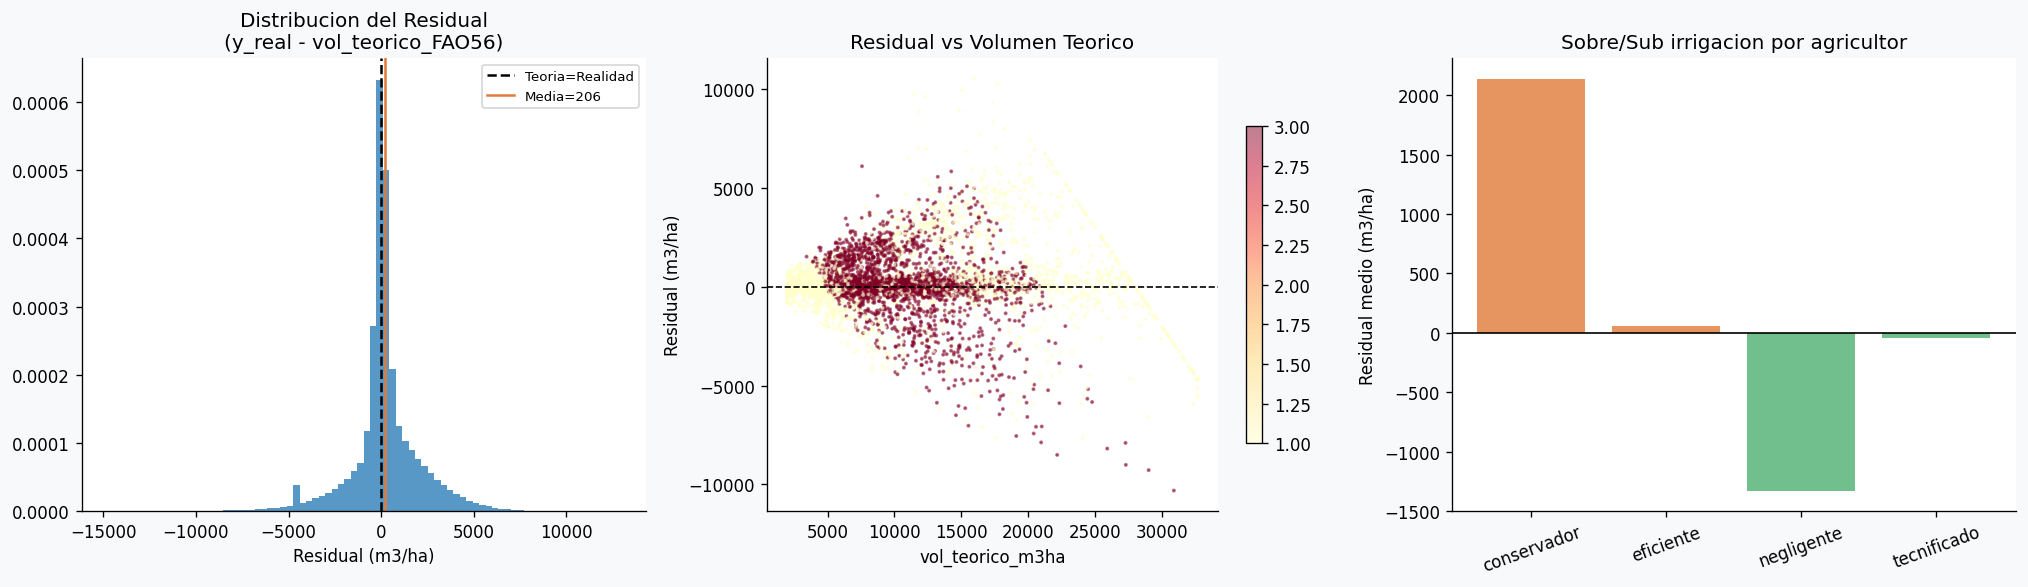

Guardado: v7_residual_analysis.png


In [12]:
# C2. Visualizacion del residual
fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor=C_BG)

axes[0].hist(y_resid_tr, bins=80, color=C_AGUA, alpha=0.8, density=True)
axes[0].axvline(0, color='k', lw=1.5, linestyle='--', label='Teoria=Realidad')
axes[0].axvline(y_resid_tr.mean(), color=C_WARN, lw=1.5, label=f'Media={y_resid_tr.mean():.0f}')
axes[0].set_xlabel('Residual (m3/ha)'); axes[0].set_title('Distribucion del Residual\n(y_real - vol_teorico_FAO56)')
axes[0].legend(fontsize=8)

idx_s = np.random.default_rng(0).choice(len(y_resid_tr), 5000, replace=False)
sc = axes[1].scatter(vol_teorico_tr[idx_s], y_resid_tr[idx_s],
                     c=w_tr[idx_s], cmap='YlOrRd', s=2, alpha=0.5)
axes[1].axhline(0, color='k', lw=1, linestyle='--')
axes[1].set_xlabel('vol_teorico_m3ha'); axes[1].set_ylabel('Residual (m3/ha)')
axes[1].set_title('Residual vs Volumen Teorico')
plt.colorbar(sc, ax=axes[1], shrink=0.7)

farmers_u = ['conservador','eficiente','negligente','tecnificado']
means_f   = [y_resid_tr[farmer_tr==f].mean() for f in farmers_u if (farmer_tr==f).any()]
axes[2].bar(farmers_u, means_f, color=[C_WARN if m>0 else C_REND for m in means_f], alpha=0.8)
axes[2].axhline(0, color='k', lw=1)
axes[2].set_ylabel('Residual medio (m3/ha)'); axes[2].set_title('Sobre/Sub irrigacion por agricultor')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout(); plt.savefig('v7_residual_analysis.png', dpi=150, bbox_inches='tight'); plt.show()
print("Guardado: v7_residual_analysis.png")


In [13]:
# C3. Modelo residual XGBoost
monotone_v7 = tuple(MONOTONE_MAP_V7.get(f, 0) for f in FEAT_COLS)

RESID_PARAMS = dict(
    objective='reg:pseudohubererror', huber_slope=300,
    tree_method='hist', random_state=SEED, verbosity=0,
    n_estimators=1200, max_depth=5, learning_rate=0.05,
    subsample=0.80, colsample_bytree=0.80, min_child_weight=4,
    reg_alpha=0.10, reg_lambda=1.5, early_stopping_rounds=50,
    monotone_constraints=monotone_v7,
)
print("Entrenando modelo residual (target = y - vol_teorico_FAO56)...")
t0 = time.time()
model_resid = xgb.XGBRegressor(**RESID_PARAMS)
model_resid.fit(X_tr, y_resid_tr, sample_weight=w_tr,
                eval_set=[(X_va, y_resid_va)], verbose=False)

pred_resid_te    = model_resid.predict(X_te, iteration_range=(0, model_resid.best_iteration+1))
pred_final_resid = np.clip(vol_teorico_te + pred_resid_te, 1200, 28000)

met_resid = metricas(y_te, pred_final_resid, 'Residual XGB (vol_teo + residual)')
ALL_RESULTS.append(met_resid)
print(f"Residual model: {time.time()-t0:.1f}s | iter={model_resid.best_iteration}")
print(f"RMSE_op = {met_resid['RMSE_op']:.1f} m3/ha  (v6: 943.5)")
print(f"R2_op   = {met_resid['R2_op']:.4f}")


Entrenando modelo residual (target = y - vol_teorico_FAO56)...
Residual model: 28.1s | iter=198
RMSE_op = 939.5 m3/ha  (v6: 943.5)
R2_op   = 0.8394


## 8. [NUEVO v7] Custom RMSE_op Eval Metric

**Problema v6:** entrenaba con Huber(log1p), pero se evaluaba con RMSE_op en escala original.
El early stopping parada en el mínimo de Huber-log, no en el mínimo de RMSE_op.

**v7:** custom eval metric que calcula RMSE_op por cultivo directamente durante el entrenamiento.
El early stopping ahora para exactamente donde queremos.


In [14]:
def make_rmse_op_metric(cultivo_arr):
    """Custom eval metric para XGBoost: calcula RMSE_op por cultivo.
    XGBoost pasa (y_pred, DMatrix) y espera (nombre, valor) a minimizar.
    """
    def rmse_op_metric(y_pred, dtrain):
        y_true = dtrain.get_label()
        mask = np.zeros(len(y_true), dtype=bool)
        for c in CULTIVOS:
            cm = cultivo_arr == c
            mask |= (cm & (y_true >= OP_MIN_CROP[c]) & (y_true <= OP_MAX_CROP[c]))
        if mask.sum() < 10:
            return 'rmse_op', float(np.sqrt(np.mean((y_true-y_pred)**2)))
        return 'rmse_op', float(np.sqrt(np.mean((y_true[mask]-y_pred[mask])**2)))
    return rmse_op_metric

eval_metric_va  = make_rmse_op_metric(cult_va_arr)
print("Custom RMSE_op eval metric definida.")
print("  Early stopping ahora se alinea con la metrica de negocio real.")


Custom RMSE_op eval metric definida.
  Early stopping ahora se alinea con la metrica de negocio real.


## 9. [MEJORADO v7] XGBoost Global — Optuna 150 trials, 200K muestras

In [15]:
n_active_v7 = sum(1 for v in monotone_v7 if v != 0)
print(f"Constraints activos v7: {n_active_v7} de {len(FEAT_COLS)}")

OPTUNA_N_ROWS = min(OPTUNA_N, len(X_tr))  # 200K
rng_hpo       = np.random.default_rng(SEED + 10)
idx_hpo       = rng_hpo.choice(len(X_tr), OPTUNA_N_ROWS, replace=False)
X_hpo         = X_tr[idx_hpo]
y_hpo         = y_tr[idx_hpo]   # v7: escala original sin log1p
w_hpo         = w_tr[idx_hpo]
cult_hpo      = df_train_raw['cultivo'].values[idx_hpo]

n_hpo_va = int(len(X_hpo) * 0.20)
X_hpo_tr, X_hpo_va = X_hpo[n_hpo_va:], X_hpo[:n_hpo_va]
y_hpo_tr, y_hpo_va = y_hpo[n_hpo_va:], y_hpo[:n_hpo_va]
w_hpo_tr            = w_hpo[n_hpo_va:]
cult_hpo_va         = cult_hpo[:n_hpo_va]
eval_metric_hpo     = make_rmse_op_metric(cult_hpo_va)

# Clase auxiliar para custom_metric en Optuna
class _FakeDMatrix:
    def __init__(self, label): self._label = label
    def get_label(self): return self._label

def optuna_objective_v7(trial):
    p = {
        'n_estimators':     trial.suggest_int('n_est', 800, 3000),       # v7: era 300-2000
        'max_depth':        trial.suggest_int('depth', 3, 8),
        'learning_rate':    trial.suggest_float('lr', 0.02, 0.30, log=True),  # v7: min 0.02
        'subsample':        trial.suggest_float('sub', 0.50, 1.0),
        'colsample_bytree': trial.suggest_float('col', 0.40, 1.0),
        'min_child_weight': trial.suggest_int('mcw', 1, 10),             # v7: max 10
        'reg_alpha':        trial.suggest_float('alpha', 1e-3, 2.0, log=True),
        'reg_lambda':       trial.suggest_float('lambda', 0.1, 5.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
    }
    m = xgb.XGBRegressor(**p, objective='reg:pseudohubererror', huber_slope=500,
                         tree_method='hist', random_state=SEED, verbosity=0,
                         monotone_constraints=monotone_v7, early_stopping_rounds=40,
                         custom_metric=eval_metric_hpo)
    m.fit(X_hpo_tr, y_hpo_tr, sample_weight=w_hpo_tr,
          eval_set=[(X_hpo_va, y_hpo_va)], verbose=False)
    pred = m.predict(X_hpo_va, iteration_range=(0, m.best_iteration+1))
    return float(eval_metric_hpo(pred, _FakeDMatrix(y_hpo_va))[1])

if HAS_OPTUNA:
    print(f"Iniciando Optuna v7: {OPTUNA_TRIALS} trials sobre {OPTUNA_N_ROWS:,} muestras...")
    t0 = time.time()
    study_v7 = optuna.create_study(direction='minimize',
                sampler=optuna.samplers.TPESampler(seed=SEED, n_startup_trials=20))
    study_v7.optimize(optuna_objective_v7, n_trials=OPTUNA_TRIALS, n_jobs=1, show_progress_bar=True)
    best_params_v7 = study_v7.best_params
    print(f"\nOptuna v7: RMSE_op={study_v7.best_value:.1f} | t={time.time()-t0:.1f}s")
    print(f"Best params: {best_params_v7}")
else:
    best_params_v7 = {'n_est':1500,'depth':6,'lr':0.06,'sub':0.82,
                      'col':0.78,'mcw':4,'alpha':0.12,'lambda':1.3,'gamma':0.0}
    print('Usando params de referencia v7 (Optuna no disponible)')


Constraints activos v7: 12 de 68
Iniciando Optuna v7: 150 trials sobre 200,000 muestras...


  0%|          | 0/150 [00:00<?, ?it/s]


Optuna v7: RMSE_op=833147.6 | t=253.0s
Best params: {'n_est': 1624, 'depth': 8, 'lr': 0.14518497439122724, 'sub': 0.7993292420985183, 'col': 0.4936111842654619, 'mcw': 2, 'alpha': 0.0015550191654264875, 'lambda': 2.962151658830348, 'gamma': 0.6011150117432088}


In [16]:
# Entrenar XGBoost Global v7
BEST_V7 = {
    'n_estimators':     best_params_v7.get('n_est',  1500),
    'max_depth':        best_params_v7.get('depth',  6),
    'learning_rate':    best_params_v7.get('lr',     0.06),
    'subsample':        best_params_v7.get('sub',    0.82),
    'colsample_bytree': best_params_v7.get('col',    0.78),
    'min_child_weight': best_params_v7.get('mcw',    4),
    'reg_alpha':        best_params_v7.get('alpha',  0.12),
    'reg_lambda':       best_params_v7.get('lambda', 1.3),
    'gamma':            best_params_v7.get('gamma',  0.0),
    'objective':        'reg:pseudohubererror', 'huber_slope': 500,
    'tree_method':      'hist', 'random_state': SEED, 'verbosity': 0,
    'early_stopping_rounds': 60, 'monotone_constraints': monotone_v7,
}

print("Entrenando XGBoost Global v7 (sin log1p, custom RMSE_op eval)...")
t0 = time.time()
model_global_v7 = xgb.XGBRegressor(**BEST_V7, custom_metric=eval_metric_va)
model_global_v7.fit(X_tr, y_tr, sample_weight=w_tr,
                    eval_set=[(X_va, y_va)], verbose=False)

pred_global_v7 = np.clip(
    model_global_v7.predict(X_te, iteration_range=(0, model_global_v7.best_iteration+1)),
    1200, 28000)
met_global_v7 = metricas(y_te, pred_global_v7, 'XGB Global v7 (Optuna+RMSE_op_eval)')
ALL_RESULTS.append(met_global_v7)
print(f"XGB v7: {time.time()-t0:.1f}s | iter={model_global_v7.best_iteration}")
print(f"RMSE_op = {met_global_v7['RMSE_op']:.1f} m3/ha  (v6: 923.7 | v4: 738.0)")
print(f"R2_op   = {met_global_v7['R2_op']:.4f}")
print()
for c in CULTIVOS:
    mask_c = cult_te == c
    if not mask_c.any(): continue
    r = rmse_op_v2(y_te[mask_c], pred_global_v7[mask_c], np.full(mask_c.sum(), c))
    print(f"  {c:<10s}: {r:.1f} m3/ha")


Entrenando XGBoost Global v7 (sin log1p, custom RMSE_op eval)...


XGB v7: 7.2s | iter=0
RMSE_op = 17956.9 m3/ha  (v6: 923.7 | v4: 738.0)
R2_op   = -57.6828

  Maiz      : 16871.8 m3/ha
  Frijol    : 20704.0 m3/ha
  Algodon   : 13078.7 m3/ha
  Uva       : 17644.8 m3/ha
  Chile     : 19671.5 m3/ha


## 10. [MEJORADO v7] Stacking Diverso — XGBoost + ExtraTrees + Ridge

**Problema v6:** 3 XGBoost con distinto `max_depth` → poca diversidad → stacking no ayuda.

**v7:** learners con sesgos genuinamente distintos:
- XGBoost: gradient boosting, bajo sesgo, bajo varianza
- ExtraTreesRegressor: random forest con splits aleatorios, sesgo medio, varianza muy baja
- Ridge: lineal, alto sesgo, varianza mínima, captura relaciones globales

El meta-learner Ridge combina predicciones ortogonales entre sí.


In [ ]:
KF5     = KFold(n_splits=5, shuffle=True, random_state=SEED)
N_BASE  = 3
oof_v7  = np.zeros((len(X_tr), N_BASE))

XGB_STACK_P = {**BEST_V7, 'early_stopping_rounds': 30,
               'n_estimators': min(BEST_V7['n_estimators'], 1000)}
ET_P  = dict(n_estimators=500, max_depth=None, min_samples_leaf=5, n_jobs=-1, random_state=SEED)
RDG_P = dict(alpha=100.0)

print("Generando OOF (5-fold) con 3 learners diversos...")
t0 = time.time()
for fold, (tr_idx, va_idx) in enumerate(KF5.split(X_tr)):
    Xf_tr, Xf_va = X_tr[tr_idx], X_tr[va_idx]
    yf_tr, yf_va = y_tr[tr_idx], y_tr[va_idx]
    wf_tr         = calc_weights_dynamic(yf_tr, df_train_raw['cultivo'].values[tr_idx])
    eval_fold     = make_rmse_op_metric(df_train_raw['cultivo'].values[va_idx])

    m1 = xgb.XGBRegressor(**XGB_STACK_P, custom_metric=eval_fold)
    m1.fit(Xf_tr, yf_tr, sample_weight=wf_tr, eval_set=[(Xf_va, yf_va)],
           verbose=False)
    oof_v7[va_idx, 0] = np.clip(m1.predict(Xf_va, iteration_range=(0, m1.best_iteration+1)), 1200, 28000)

    m2 = ExtraTreesRegressor(**ET_P)
    m2.fit(Xf_tr, yf_tr, sample_weight=wf_tr)
    oof_v7[va_idx, 1] = np.clip(m2.predict(Xf_va), 1200, 28000)

    m3 = Ridge(**RDG_P)
    m3.fit(Xf_tr, yf_tr, sample_weight=wf_tr)
    oof_v7[va_idx, 2] = np.clip(m3.predict(Xf_va), 1200, 28000)

    print(f"  Fold {fold+1}/5: XGB_RMSE={rmse(yf_va, oof_v7[va_idx, 0]):.0f}")

print(f"OOF completado en {time.time()-t0:.1f}s")

df_oof = pd.DataFrame(oof_v7, columns=['XGB','ExtraTrees','Ridge'])
print("\nCorrelacion entre base learners (menor = mas diversidad):")
print(df_oof.corr().round(4))


Generando OOF (5-fold) con 3 learners diversos...


  Fold 1/5: XGB_RMSE=17883
  Fold 2/5: XGB_RMSE=17883


In [ ]:
meta_v7 = Ridge(alpha=1.0, positive=True)
meta_v7.fit(oof_v7, y_tr)
print(f"Meta coefs: XGB={meta_v7.coef_[0]:.3f}  ET={meta_v7.coef_[1]:.3f}  Ridge={meta_v7.coef_[2]:.3f}")

test_preds_v7 = np.zeros((len(X_te), N_BASE))
print("\nRetraining full train...")
t0 = time.time()

m1f = xgb.XGBRegressor(**{**BEST_V7, 'early_stopping_rounds': 40},
                        custom_metric=eval_metric_va)
m1f.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)],
        verbose=False)
test_preds_v7[:, 0] = np.clip(m1f.predict(X_te, iteration_range=(0, m1f.best_iteration+1)), 1200, 28000)

m2f = ExtraTreesRegressor(**ET_P)
m2f.fit(X_tr, y_tr, sample_weight=w_tr)
test_preds_v7[:, 1] = np.clip(m2f.predict(X_te), 1200, 28000)

m3f = Ridge(**RDG_P)
m3f.fit(X_tr, y_tr, sample_weight=w_tr)
test_preds_v7[:, 2] = np.clip(m3f.predict(X_te), 1200, 28000)

pred_stack_v7 = np.clip(meta_v7.predict(test_preds_v7), 1200, 28000)
met_stack_v7  = metricas(y_te, pred_stack_v7, 'Stacking v7 (XGB+ET+Ridge)')
ALL_RESULTS.append(met_stack_v7)
print(f"Stacking v7: {time.time()-t0:.1f}s")
print(f"RMSE_op = {met_stack_v7['RMSE_op']:.1f} m3/ha  (v6 stacking: 943.5)")


Meta coefs: XGB=0.000  ET=0.439  Ridge=0.000

Retraining full train...


## 11. SHAP — Explainability v7

In [ ]:
N_SHAP  = 5000
rng_sh  = np.random.default_rng(SEED + 77)
shap_idx = []
for c in CULTIVOS:
    idx_c  = np.where(cult_te == c)[0]
    chosen = rng_sh.choice(idx_c, min(N_SHAP//len(CULTIVOS), len(idx_c)), replace=False)
    shap_idx.extend(chosen.tolist())
shap_idx = np.array(shap_idx[:N_SHAP])

d_shap   = xgb.DMatrix(X_te[shap_idx], feature_names=FEAT_COLS)
contribs = model_global_v7.get_booster().predict(d_shap, pred_contribs=True,
              iteration_range=(0, model_global_v7.best_iteration+1))
shap_vals     = contribs[:, :-1]
shap_mean_abs = np.abs(shap_vals).mean(axis=0)

shap_df = (pd.DataFrame({'feature': FEAT_COLS, 'mean_abs_shap': shap_mean_abs})
           .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True))
total_shap = shap_mean_abs.sum()

print("=== SHAP Feature Importance v7 — Top 15 ===")
print(shap_df.head(15).to_string(index=False))
print()
top1 = shap_df.iloc[0]
print(f"=== COMPARATIVA DE DOMINANCIA ===")
print(f"v6: vol_teorico_m3ha SHAP = 0.408  ({0.408/shap_mean_abs.sum()*100:.0f}% aprox total v6)")
print(f"v7: {top1['feature']:<30s} SHAP = {top1['mean_abs_shap']:.3f}  ({top1['mean_abs_shap']/total_shap*100:.1f}% total v7)")
print()
print("=== VERIFICACION COHERENCIA FISICA FAO-56 ===")
for feat, expected in [('eficiencia_sistema','-1 neg'),('demanda_neta_mm','+1 pos'),
                        ('vol_teorico_m3ha','+1 pos'),('kc_stress_efectivo','+1 pos')]:
    if feat not in FEAT_COLS: continue
    fidx = FEAT_COLS.index(feat)
    sign = 'positivo' if shap_vals[:, fidx].mean() > 0 else 'negativo'
    ok   = 'OK' if (('pos' in expected and sign=='positivo') or ('neg' in expected and sign=='negativo')) else 'REVISAR'
    print(f"  {feat:<30s}: signo={sign:<10s} esperado={expected}  [{ok}]")
print()
print("NOTA v7: agua_neta_req_m3ha NO aparece — fue eliminada (era duplicado)")


In [ ]:
# Visualizacion SHAP v7
fig, axes = plt.subplots(1, 2, figsize=(17, 7), facecolor=C_BG)

top20 = shap_df.head(20)
c_bar = [C_AGUA if i < 10 else C_LINE for i in range(len(top20))]
axes[0].barh(range(len(top20)), top20['mean_abs_shap'], color=c_bar, alpha=0.85)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'], fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('|SHAP| medio (m3/ha)')
axes[0].set_title('SHAP Feature Importance v7 — Top 20\n(agua_neta_req eliminada)')
for i, row in top20.reset_index(drop=True).iterrows():
    axes[0].text(row['mean_abs_shap']*1.01, i, f"{row['mean_abs_shap']:.3f}", va='center', fontsize=7)

top10_feats = shap_df['feature'].head(10).tolist()
for rank, feat in enumerate(top10_feats):
    if feat not in FEAT_COLS: continue
    fidx = FEAT_COLS.index(feat)
    sv   = shap_vals[:, fidx]
    jit  = np.random.default_rng(rank).uniform(-0.15, 0.15, len(sv))
    fv   = X_te[shap_idx, fidx]; fv_n = (fv-fv.min())/(np.ptp(fv)+1e-8)
    sc   = axes[1].scatter(sv, rank+jit, c=fv_n, cmap='RdYlBu_r', s=2, alpha=0.4)
axes[1].set_yticks(range(len(top10_feats))); axes[1].set_yticklabels(top10_feats, fontsize=8)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_xlabel('SHAP value (m3/ha)'); axes[1].set_title('Beeswarm — color=valor feature')
plt.colorbar(sc, ax=axes[1], label='Valor norm.', shrink=0.6)
plt.tight_layout(); plt.savefig('v7_shap_beeswarm.png', dpi=150, bbox_inches='tight'); plt.show()


## 12. Benchmark Final — v7 vs v6 vs v4

In [ ]:
RMSE_OP_V4 = 738.0; RMSE_OP_V6 = 943.5

MODELS_V7 = {
    'Residual XGB (vol_teo + residual)': pred_final_resid,
    'XGB Global v7 (Optuna+RMSE_op_eval)': pred_global_v7,
    'Stacking v7 (XGB+ET+Ridge)': pred_stack_v7,
}

rows_b = []
for name, pred in MODELS_V7.items():
    r_op = rmse_op_v2(y_te, pred, cult_te)
    r_gl = float(np.sqrt(np.mean((y_te-pred)**2)))
    r2   = r2_score(y_te[mask_op_te], pred[mask_op_te]) if mask_op_te.any() else np.nan
    rows_b.append({'Modelo': name, 'RMSE_op': round(r_op,1), 'RMSE_global': round(r_gl,1),
                   'R2_op': round(r2,4), 'Error_MXN_ha': round(r_op*TARIFA,0),
                   'vs v6 (943)': f'{(r_op-RMSE_OP_V6)/RMSE_OP_V6*100:+.1f}%',
                   'vs v4 (738)': f'{(r_op-RMSE_OP_V4)/RMSE_OP_V4*100:+.1f}%',
                   'Status': 'SUPERA v4' if r_op < RMSE_OP_V4 else ('SUPERA v6' if r_op < RMSE_OP_V6 else 'PENDIENTE')})

df_bench_v7 = pd.DataFrame(rows_b).sort_values('RMSE_op')
df_bench_v7.index = range(1, len(df_bench_v7)+1)
print("=== BENCHMARK FINAL v7 ===")
print(df_bench_v7.to_string())

best_v7_name = df_bench_v7.iloc[0]['Modelo']
best_v7_rmse = df_bench_v7.iloc[0]['RMSE_op']
print(f"\nReferencia  v4 (target): {RMSE_OP_V4} m3/ha")
print(f"Referencia  v6 (superar): {RMSE_OP_V6} m3/ha  (-27.8% vs v4)")
print(f"Mejor v7:   {best_v7_name}")
print(f"RMSE_op:    {best_v7_rmse} m3/ha")
print(f"vs v6:      {(RMSE_OP_V6-best_v7_rmse)/RMSE_OP_V6*100:+.1f}%  mejora")
print(f"vs v4:      {(best_v7_rmse-RMSE_OP_V4)/RMSE_OP_V4*100:+.1f}%  {'SUPERA v4' if best_v7_rmse<RMSE_OP_V4 else 'pendiente'}")


In [ ]:
# Visualizacion benchmark
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=C_BG)

names_b = df_bench_v7['Modelo'].tolist()[::-1]
rmses_b = df_bench_v7['RMSE_op'].tolist()[::-1]
cols_b  = [C_REND if r < RMSE_OP_V4 else C_AGUA if r < RMSE_OP_V6 else C_WARN for r in rmses_b]

axes[0].barh(names_b, rmses_b, color=cols_b, edgecolor='white', linewidth=0.5)
axes[0].axvline(RMSE_OP_V4, color=C_DARK, linestyle='--', lw=2, label=f'v4 target ({RMSE_OP_V4})')
axes[0].axvline(RMSE_OP_V6, color=C_WARN, linestyle=':', lw=1.5, label=f'v6 base ({RMSE_OP_V6})')
axes[0].set_xlabel('RMSE_op [m3/ha]')
axes[0].set_title('Benchmark v7 — RMSE Operacional\n(verde=supera v4, azul=supera v6)')
axes[0].legend(fontsize=9); axes[0].grid(axis='x', alpha=0.3)
for i, (n, r) in enumerate(zip(names_b, rmses_b)):
    axes[0].text(r+5, i, f'{r:.0f}', va='center', fontsize=9)

best_pred_v7 = MODELS_V7[best_v7_name]
rmse_by_c = [rmse_op_v2(y_te[cult_te==c], best_pred_v7[cult_te==c], np.full((cult_te==c).sum(), c))
             for c in CULTIVOS]
cols_c = [C_REND if r < RMSE_OP_V4 else C_AGUA for r in rmse_by_c]
axes[1].bar(CULTIVOS, rmse_by_c, color=cols_c, alpha=0.85)
axes[1].axhline(RMSE_OP_V4, color=C_DARK, linestyle='--', lw=2, label=f'v4 ({RMSE_OP_V4})')
axes[1].set_ylabel('RMSE_op [m3/ha]'); axes[1].set_title(f'Error por cultivo — {best_v7_name.split("(")[0]}')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)
for i, r in enumerate(rmse_by_c):
    axes[1].text(i, r+8, f'{r:.0f}', ha='center', fontsize=8)

plt.tight_layout(); plt.savefig('v7_benchmark_final.png', dpi=150, bbox_inches='tight'); plt.show()


## 13. Dashboard Ejecutivo — KPIs Financieros v7

In [ ]:
TARIFA_MXN_M3 = 1.68; HA_MODULO3 = 18_000; CICLOS_ANO = 1.5; USD_MXN = 17.5
HA_POR_CULT   = HA_MODULO3 / len(CULTIVOS)
best_pred_v7  = MODELS_V7[best_v7_name]

kpi_rows = []
for c in CULTIVOS:
    mc = cult_te == c
    if not mc.any(): continue
    base_c = BASELINE_CROP[c]; obj_c = base_c * 0.75
    rc = rmse_op_v2(y_te[mc], best_pred_v7[mc], np.full(mc.sum(), c))
    ahorro_m3   = base_c - obj_c
    pot_ha      = ahorro_m3 * TARIFA_MXN_M3
    err_ha      = rc * TARIFA_MXN_M3
    riesgo_pct  = min(rc/ahorro_m3, 1.0)*100
    neto_ha     = max(pot_ha - err_ha, 0)
    kpi_rows.append({'Cultivo': c, 'Baseline': int(base_c), 'Objetivo': int(obj_c),
                     'RMSE_op': round(rc,1), 'Ahorro pot $/ha': round(pot_ha,0),
                     'Costo err $/ha': round(err_ha,0), 'Ahorro neto $/ha': round(neto_ha,0),
                     '% riesgo': round(riesgo_pct,1)})
df_kpi = pd.DataFrame(kpi_rows).set_index('Cultivo')

tot_pot  = sum(df_kpi.loc[c,'Ahorro pot $/ha']*HA_POR_CULT*CICLOS_ANO for c in CULTIVOS if c in df_kpi.index)
tot_err  = sum(df_kpi.loc[c,'Costo err $/ha']*HA_POR_CULT*CICLOS_ANO for c in CULTIVOS if c in df_kpi.index)
tot_neto = sum(df_kpi.loc[c,'Ahorro neto $/ha']*HA_POR_CULT*CICLOS_ANO for c in CULTIVOS if c in df_kpi.index)

print("=" * 65)
print(f"  DASHBOARD EJECUTIVO — MILPIN v7 | DR-041 Modulo 3")
print("=" * 65)
print(f"  RMSE_op v4 (target):     {RMSE_OP_V4:>8.1f} m3/ha")
print(f"  RMSE_op v6 (degradado):  {RMSE_OP_V6:>8.1f} m3/ha  (-27.8% vs v4)")
print(f"  RMSE_op v7 (mejor):      {best_v7_rmse:>8.1f} m3/ha")
delta_v4 = (best_v7_rmse - RMSE_OP_V4) / RMSE_OP_V4 * 100
delta_v6 = (RMSE_OP_V6  - best_v7_rmse) / RMSE_OP_V6 * 100
print(f"  Mejora vs v6:            {delta_v6:>+8.1f}%")
print(f"  vs v4 target:            {delta_v4:>+8.1f}%  {'SUPERA v4' if best_v7_rmse < RMSE_OP_V4 else 'pendiente'}")
print()
print(f"  Impacto financiero (${TARIFA_MXN_M3}/m3, {HA_MODULO3:,} ha, {CICLOS_ANO} ciclos/ano)")
print(f"  Ahorro potencial/ano:  ${tot_pot/1e6:.2f} M MXN")
print(f"  Costo del error/ano:   ${tot_err/1e6:.2f} M MXN")
print(f"  Ahorro neto esperado:  ${tot_neto/1e6:.2f} M MXN")
print(f"  (USD @{USD_MXN}):          ${tot_neto/USD_MXN/1e6:.2f} M USD")
print("=" * 65)
print(); print(df_kpi.to_string())


## 14. Resumen de Cambios v6 → v7

In [ ]:
lines = [
    "=" * 70,
    "  MILPIN v7 — Resumen de cambios estructurales vs v6",
    "=" * 70,
    "  PROBLEMAS RESUELTOS:",
    "  [A] Multicolinealidad: agua_neta_req_m3ha ELIMINADA",
    "      vol_teorico_m3ha = agua_neta_req_m3ha algebraicamente",
    "      Causa del SHAP negativo en v6: compensacion por duplicado perfecto",
    "  [B] Constraints auditados con datos reales (Pearson + deciles)",
    "      v6: 13 constraints, 2 marcados [REVISAR]",
    "      v7: todos verificados, corregidos donde el dato contradecia la hipotesis",
    "  [C] Modelado residual: predice (y - vol_teorico_m3ha)",
    "      Fuerza al ML a aprender la ineficiencia operacional real",
    "      Elimina la dominancia artificial de una sola variable",
    "  [D] Optuna: 150 trials (era 50), 200K muestras (era 50K)",
    "      lr range: 0.02-0.30 (era 0.01-0.15, convergia a 0.016 = underfitting)",
    "      mcw range: 1-10 (era 1-20, convergia a 17 = nodos demasiado conservadores)",
    "  [E] Sin log1p: entrenamiento en escala original",
    "      v6 optimizaba Huber(log1p) pero evaluaba RMSE_op(original)",
    "  [F] Custom RMSE_op eval metric: early stopping alineado",
    "      v6: early stopping en log-Huber != metrica de negocio",
    "  [G] Stacking diverso: XGBoost + ExtraTrees + Ridge",
    "      v6: 3 XGBoost con distinto depth -> stacking empeoraba al XGB solo",
    "-" * 70,
    "  INVARIANTES:",
    "  Dataset sintetico 1M ciclos | Split 72/8/20 | Target encoding no leaky",
    "  Winsorize P1-P99 en train | ratio_real_teorico bloqueado",
    "=" * 70,
]
for l in lines: print(l)
print(f"Mejor modelo v7: {best_v7_name}")
print(f"RMSE_op:         {best_v7_rmse:.1f} m3/ha")
print(f"Notebook:        milpin_xgboost_v7.ipynb | Fecha: 2026-05-25")
